**⚠️ NUMPY COMPATIBILITY FIX:**

The "Numpy is not available" error happens when NumPy 2.x is installed with PyTorch 2.2.x.

**Solution:** Run this in terminal:
```bash
cd /Users/anton/Documents/GitHub/Final_Year_Project
python3 -m pip install 'numpy<2.0' 'opencv-python<4.13'
```

Then **restart the kernel** (Kernel → Restart Kernel) and run all cells from the top.

## 1. Environment Setup

First, we'll install all required packages and verify that we have access to a GPU for training.

In [ ]:
# Install required packages
import subprocess
import sys

print(f"Using Python: {sys.executable}")

# Remove conflicting headless OpenCV if present (often pulls NumPy>=2)
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "opencv-python-headless"], check=False)

# Force-reinstall key packages to ensure a consistent environment
core_packages = [
    "numpy<2.0",
    "torch==2.2.2",
    "torchvision==0.17.2",
    "opencv-python<4.13",
]

print("Installing core packages (forced reinstall)...")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--force-reinstall", "--no-cache-dir",
    *core_packages
])

packages = [
    "ultralytics>=8.0.0",
    "scikit-learn>=1.3.0",
    "matplotlib>=3.7.0",
    "seaborn>=0.12.0",
    "pyyaml>=6.0",
    "tqdm>=4.65.0",
]

print("\nInstalling remaining packages...")
for package in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    except subprocess.CalledProcessError:
        print(f"Warning: Failed to install {package}")

print("\n✓ All packages installed!")
print("⚠️  IMPORTANT: Please restart the kernel (Kernel → Restart) before proceeding!")

Using Python: /usr/local/bin/python3
Installing core packages (forced reinstall)...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/150.8 MB ? eta -:--:--Collecting MarkupSafe>=2.0 (from jinja2->torch==2.2.2)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 86.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 86.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.7 MB/s eta 0:0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip



Installing remaining packages...



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgr


✓ All packages installed!
⚠️  IMPORTANT: Please restart the kernel (Kernel → Restart) before proceeding!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
# Import libraries
import os
import json
import sys
import time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from ultralytics import YOLO
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from tqdm.auto import tqdm

# Sanity check: ensure torch can access numpy
try:
    _ = torch.from_numpy(np.array([1, 2, 3], dtype=np.float32))
    numpy_ok = True
except Exception as exc:
    numpy_ok = False
    print("⚠️ NumPy-PyTorch interop failed:", exc)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All imports successful!")
print(f"  Python executable: {sys.executable}")
print(f"  NumPy version: {np.__version__}")
print(f"  NumPy path: {np.__file__}")
print(f"  PyTorch version: {torch.__version__}")
print(f"  PyTorch path: {torch.__file__}")
print(f"  OpenCV version: {cv2.__version__}")
print(f"  OpenCV path: {cv2.__file__}")
print(f"  NumPy-PyTorch interop: {'OK' if numpy_ok else 'FAILED'}")

if not numpy_ok:
    raise RuntimeError(
        "NumPy-PyTorch interop failed. Restart the kernel and rerun Cell 3 then Cell 4."
    )

✓ All imports successful!
  Python executable: /usr/local/bin/python3
  NumPy version: 1.26.4
  NumPy path: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/numpy/__init__.py
  PyTorch version: 2.2.2
  PyTorch path: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/__init__.py
  OpenCV version: 4.11.0
  OpenCV path: /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cv2/__init__.py
  NumPy-PyTorch interop: OK


In [5]:
# Check GPU availability
print("=" * 70)
print("HARDWARE CONFIGURATION")
print("=" * 70)

# Check CUDA
if torch.cuda.is_available():
    print(f"✓ GPU Available: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    device = "0"  # Use first GPU
else:
    print("⚠ No GPU detected - using CPU (training will be slower)")
    device = "cpu"

print(f"  PyTorch Version: {torch.__version__}")
print(f"  Device: {device}")
print("=" * 70)

HARDWARE CONFIGURATION
⚠ No GPU detected - using CPU (training will be slower)
  PyTorch Version: 2.2.2
  Device: cpu


## 2. Data Preparation

### 2.1 Configure Data Path

The dataset is available in the current project directory.

In [6]:
# Configuration
PROJECT_ROOT = Path.cwd()  # Current notebook directory
DATA_PATH = PROJECT_ROOT  # Data is in current directory

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Path: {DATA_PATH}")

Project Root: /Users/anton/Documents/GitHub/Final_Year_Project
Data Path: /Users/anton/Documents/GitHub/Final_Year_Project


In [5]:
# Check if dataset exists in current directory
import subprocess

# Check for the dataset directory
dataset_dir = DATA_PATH / "concrete-crack-images-for-classification"

if dataset_dir.exists():
    print(f"✓ Dataset directory found: {dataset_dir}")
    
    # Check for Positive/Negative folders
    positive_dir = dataset_dir / "Positive"
    negative_dir = dataset_dir / "Negative"
    
    if positive_dir.exists() and negative_dir.exists():
        pos_count = len(list(positive_dir.glob("*.jpg")) + list(positive_dir.glob("*.png")))
        neg_count = len(list(negative_dir.glob("*.jpg")) + list(negative_dir.glob("*.png")))
        print(f"  Positive (cracked): {pos_count} images")
        print(f"  Negative (not cracked): {neg_count} images")
        print(f"  Total: {pos_count + neg_count} images")
    else:
        print("⚠ Positive/Negative folders not found in dataset directory")
else:
    print(f"✗ Dataset directory not found: {dataset_dir}")
    print("\nPlease ensure the dataset is in the current directory.")
    print("Expected structure:")
    print("  concrete-crack-images-for-classification/")
    print("    Positive/")
    print("    Negative/")

✓ Dataset directory found: /Users/anton/Documents/GitHub/Final_Year_Project/concrete-crack-images-for-classification
  Positive (cracked): 20000 images
  Negative (not cracked): 20000 images
  Total: 40000 images


### 2.2 Setup Raw Classification Data Structure

We'll create a standard structure with `cracked` and `not_cracked` folders.

In [6]:
# Setup raw_classification structure using symlinks to existing data
dataset_dir = DATA_PATH / "concrete-crack-images-for-classification"
raw_classification = DATA_PATH / "raw_classification"

dataset_exists = False

# Create raw_classification directory structure if it doesn't exist
if not raw_classification.exists():
    print("Creating raw_classification structure...")
    raw_classification.mkdir(exist_ok=True)
    
    # Create symlinks to Positive (cracked) and Negative (not_cracked)
    positive_dir = dataset_dir / "Positive"
    negative_dir = dataset_dir / "Negative"
    
    cracked_link = raw_classification / "cracked"
    not_cracked_link = raw_classification / "not_cracked"
    
    if positive_dir.exists() and negative_dir.exists():
        if cracked_link.exists() or cracked_link.is_symlink():
            cracked_link.unlink()
        cracked_link.symlink_to(positive_dir.resolve())
        
        if not_cracked_link.exists() or not_cracked_link.is_symlink():
            not_cracked_link.unlink()
        not_cracked_link.symlink_to(negative_dir.resolve())
        
        print("✓ Created symlinks:")
        print(f"  cracked -> {positive_dir}")
        print(f"  not_cracked -> {negative_dir}")
    else:
        print("✗ Source directories not found")
        print(f"  Looking for: {positive_dir}")
        print(f"  Looking for: {negative_dir}")

# Verify and count images
if raw_classification.exists():
    cracked_check = raw_classification / "cracked"
    not_cracked_check = raw_classification / "not_cracked"
    
    if cracked_check.exists() and not_cracked_check.exists():
        # Count images
        extensions = {".jpg", ".jpeg", ".png", ".bmp"}
        cracked_count = len([p for p in cracked_check.iterdir() if p.suffix.lower() in extensions])
        not_cracked_count = len([p for p in not_cracked_check.iterdir() if p.suffix.lower() in extensions])
        
        if cracked_count > 0 and not_cracked_count > 0:
            dataset_exists = True
            print(f"\n✓ Dataset ready!")
            print(f"  Cracked: {cracked_count} images")
            print(f"  Not cracked: {not_cracked_count} images")
            print(f"  Total: {cracked_count + not_cracked_count} images")
        else:
            print("\n⚠ Dataset directories exist but no images found")
    else:
        print("\n⚠ cracked/not_cracked directories not found in raw_classification")

if not dataset_exists:
    print("\n✗ Dataset not properly configured")
    print("Please ensure the dataset exists in:")
    print(f"  {dataset_dir}")


✓ Dataset ready!
  Cracked: 20000 images
  Not cracked: 20000 images
  Total: 40000 images


In [7]:
# Verify data structure is ready
print("Verifying data structure...")
print()

# Check for classification data
raw_classification = DATA_PATH / "raw_classification"
if raw_classification.exists():
    print("✓ Classification data structure:")
    for class_dir in sorted(raw_classification.iterdir()):
        if class_dir.is_dir():
            num_images = len(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png")))
            print(f"  - {class_dir.name}: {num_images} images")
else:
    print("✗ raw_classification directory not found")

print()

# Check for segmentation data (optional)
raw_segmentation = DATA_PATH / "raw_segmentation"
if raw_segmentation.exists():
    images_dir = raw_segmentation / "images"
    masks_dir = raw_segmentation / "masks"
    if images_dir.exists() and masks_dir.exists():
        num_images = len(list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")))
        num_masks = len(list(masks_dir.glob("*.jpg")) + list(masks_dir.glob("*.png")))
        print(f"✓ Segmentation data found:")
        print(f"  - Images: {num_images}")
        print(f"  - Masks: {num_masks}")
else:
    print("⚠ Segmentation data not found (optional)")

Verifying data structure...

✓ Classification data structure:
  - cracked: 20000 images
  - not_cracked: 20000 images

⚠ Segmentation data not found (optional)


### 2.3 Visualize Sample Images

Let's look at some examples from the dataset to understand what we're working with.

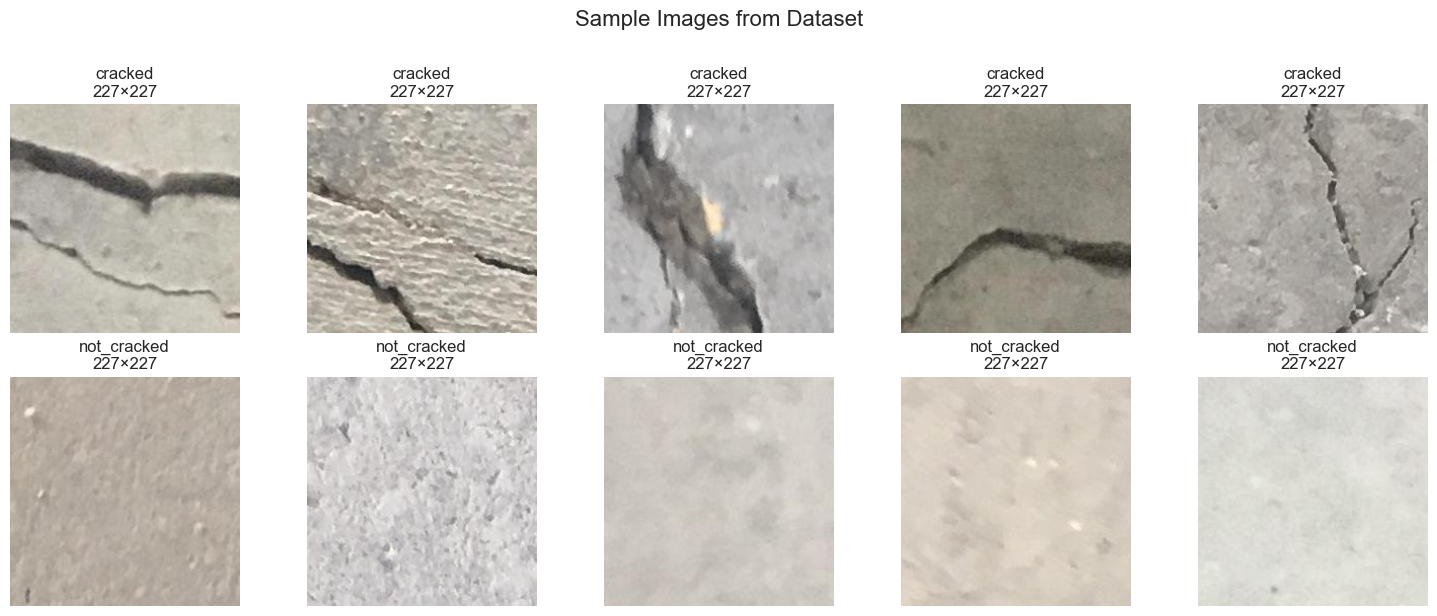

In [8]:
# Visualize random samples from each class
def visualize_classification_samples(data_path: Path, num_samples: int = 4):
    """Display random samples from each class."""
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 3, 6))
    
    class_names = ["cracked", "not_cracked"]
    raw_class = data_path / "raw_classification"
    
    for row, class_name in enumerate(class_names):
        class_dir = raw_class / class_name
        images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
        
        # Sample random images
        samples = np.random.choice(images, min(num_samples, len(images)), replace=False)
        
        for col, img_path in enumerate(samples):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            axes[row, col].imshow(img_rgb)
            axes[row, col].set_title(f"{class_name}\n{img.shape[1]}×{img.shape[0]}")
            axes[row, col].axis('off')
    
    plt.suptitle("Sample Images from Dataset", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Display samples
visualize_classification_samples(DATA_PATH, num_samples=5)

### 2.4 Prepare YOLO Classification Dataset

Now we'll convert the raw classification data into YOLO format with stratified train/val/test split.

In [9]:
# Data preparation configuration
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_SEED = 42
USE_SYMLINK = True  # Symlinks save space and are faster

print("Classification Data Preparation Configuration:")
print(f"  Train ratio: {TRAIN_RATIO}")
print(f"  Val ratio: {VAL_RATIO}")
print(f"  Test ratio: {TEST_RATIO}")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Use symlinks: {USE_SYMLINK}")

Classification Data Preparation Configuration:
  Train ratio: 0.8
  Val ratio: 0.1
  Test ratio: 0.1
  Random seed: 42
  Use symlinks: True


In [7]:
# Import data preparation script functionality
import hashlib
import shutil
from pathlib import Path
from typing import List


def get_image_paths(root_dir: Path, class_name: str) -> List[Path]:
    """Get all image paths for a given class."""
    class_dir = root_dir / class_name
    if not class_dir.exists():
        raise FileNotFoundError(f"Directory not found: {class_dir}")
    extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    return sorted([p for p in class_dir.iterdir() if p.suffix.lower() in extensions])


def file_sha256(file_path: Path, chunk_size: int = 1024 * 1024) -> str:
    """Compute SHA-256 hash of a file."""
    digest = hashlib.sha256()
    with file_path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def deduplicate_by_hash(files: List[Path], labels: List[int]):
    """
    Remove exact duplicate images (by SHA-256) before splitting.
    Raises ValueError if the same image appears under two different class labels.
    Returns (unique_files, unique_labels, duplicate_records).
    """
    seen_hashes: dict = {}
    unique_files: List[Path] = []
    unique_labels: List[int] = []
    duplicate_records = []

    for file_path, label in zip(files, labels):
        h = file_sha256(file_path)
        previous = seen_hashes.get(h)
        if previous is None:
            seen_hashes[h] = (file_path, label)
            unique_files.append(file_path)
            unique_labels.append(label)
        else:
            prev_path, prev_label = previous
            if prev_label != label:
                raise ValueError(
                    f"Conflicting labels for identical images:\n"
                    f"  {prev_path} -> {prev_label}\n"
                    f"  {file_path} -> {label}"
                )
            duplicate_records.append((prev_path, file_path, label, h))

    return unique_files, unique_labels, duplicate_records


def stratified_split(files, labels, train_ratio, val_ratio, test_ratio, seed):
    """Perform stratified split."""
    from sklearn.model_selection import train_test_split
    # First split: train vs (val+test)
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        files, labels, train_size=train_ratio, stratify=labels, random_state=seed
    )

    # Second split: val vs test
    val_size = val_ratio / (val_ratio + test_ratio)
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, train_size=val_size, stratify=temp_labels, random_state=seed
    )

    return (train_files, train_labels), (val_files, val_labels), (test_files, test_labels)


# Make this cell runnable standalone
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
if "DATA_PATH" not in globals():
    DATA_PATH = PROJECT_ROOT
if "TRAIN_RATIO" not in globals():
    TRAIN_RATIO = 0.8
if "VAL_RATIO" not in globals():
    VAL_RATIO = 0.1
if "TEST_RATIO" not in globals():
    TEST_RATIO = 0.1
if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 42
if "USE_SYMLINK" not in globals():
    USE_SYMLINK = True

import numpy as np

# Check if dataset_exists was set by an earlier cell; if not, determine it now
if "dataset_exists" not in globals():
    _raw = DATA_PATH / "raw_classification"
    _cracked = _raw / "cracked"
    _not_cracked = _raw / "not_cracked"
    _exts = {".jpg", ".jpeg", ".png", ".bmp"}
    dataset_exists = (
        _cracked.exists()
        and _not_cracked.exists()
        and any(p.suffix.lower() in _exts for p in _cracked.iterdir())
        and any(p.suffix.lower() in _exts for p in _not_cracked.iterdir())
    )

# Check if dataset is ready before proceeding
if not dataset_exists:
    print("=" * 70)
    print("⚠ DATASET NOT AVAILABLE")
    print("=" * 70)
    print("Please download the dataset first using one of these methods:")
    print("\n1. Run the download cell above")
    print("2. Or manually run: python3 setup_data.py --method kaggle")
    print("3. Or download from: https://www.kaggle.com/datasets/arunrk7/surface-crack-detection")
    print("\nSee DATA_SETUP_GUIDE.md for detailed instructions")
    print("=" * 70)
    raise FileNotFoundError("Dataset not found. Please download the dataset first.")

# Gather image paths
raw_class_dir = DATA_PATH / "raw_classification"
class_names = ["cracked", "not_cracked"]

all_files = []
all_labels = []

print("Scanning dataset...")
for label_idx, class_name in enumerate(class_names):
    images = get_image_paths(raw_class_dir, class_name)
    print(f"Found {len(images)} images in '{class_name}'")
    all_files.extend(images)
    all_labels.extend([label_idx] * len(images))

print(f"\nTotal images before deduplication: {len(all_files)}")
print(f"Class distribution before deduplication: {np.bincount(all_labels)}")

# Remove exact duplicates (SHA-256) to prevent train/val/test leakage
print("\nDeduplicating by SHA-256 hash (this may take a moment)...")
all_files, all_labels, duplicate_records = deduplicate_by_hash(all_files, all_labels)

print(f"Total images after  deduplication: {len(all_files)}")
print(f"Class distribution after  deduplication: {np.bincount(all_labels)}")
if duplicate_records:
    print(f"\n⚠ Removed {len(duplicate_records)} exact duplicate image(s):")
    for orig, dup, lbl, h in duplicate_records[:10]:
        print(f"  {dup.name}  →  duplicate of  {orig.name}  (label={lbl}, hash={h[:12]}…)")
    if len(duplicate_records) > 10:
        print(f"  … and {len(duplicate_records) - 10} more")
else:
    print("✓ No exact duplicates found.")


Scanning dataset...
Found 20000 images in 'cracked'
Found 20000 images in 'not_cracked'

Total images before deduplication: 40000
Class distribution before deduplication: [20000 20000]

Deduplicating by SHA-256 hash (this may take a moment)...
Found 20000 images in 'not_cracked'

Total images before deduplication: 40000
Class distribution before deduplication: [20000 20000]

Deduplicating by SHA-256 hash (this may take a moment)...
Total images after  deduplication: 38402
Class distribution after  deduplication: [19684 18718]

⚠ Removed 1598 exact duplicate image(s):
  15411_1.jpg  →  duplicate of  15050_1.jpg  (label=0, hash=18695d5374e8…)
  15466_1.jpg  →  duplicate of  15000_1.jpg  (label=0, hash=05c0c1008ff5…)
  15540_1.jpg  →  duplicate of  15268_1.jpg  (label=0, hash=40bb73309608…)
  15559_1.jpg  →  duplicate of  15398_1.jpg  (label=0, hash=d1d4a923129e…)
  15567_1.jpg  →  duplicate of  15198_1.jpg  (label=0, hash=f3e486cf83ce…)
  15586_1.jpg  →  duplicate of  15573_1.jpg  (label

In [8]:
# Perform stratified split
print("\nPerforming stratified split...")
(train_files, train_labels), (val_files, val_labels), (test_files, test_labels) = stratified_split(
    all_files, all_labels, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_SEED
)

print(f"Train: {len(train_files)} images")
print(f"  - cracked: {sum(train_labels)}")
print(f"  - not_cracked: {len(train_labels) - sum(train_labels)}")
print(f"Val: {len(val_files)} images")
print(f"  - cracked: {sum(val_labels)}")
print(f"  - not_cracked: {len(val_labels) - sum(val_labels)}")
print(f"Test: {len(test_files)} images")
print(f"  - cracked: {sum(test_labels)}")
print(f"  - not_cracked: {len(test_labels) - sum(test_labels)}")


Performing stratified split...
Train: 30721 images
  - cracked: 14974
  - not_cracked: 15747
Val: 3840 images
  - cracked: 1872
  - not_cracked: 1968
Test: 3841 images
  - cracked: 1872
  - not_cracked: 1969


In [11]:
# Create YOLO classification structure
import shutil

classify_dir = DATA_PATH / "classify_yolo"

# Wipe any existing classify_yolo folder so stale symlinks from previous runs
# (which may have been built without deduplication) cannot cause false leakage.
if classify_dir.exists():
    shutil.rmtree(classify_dir)
    print(f"Removed existing folder: {classify_dir}")

print(f"Creating YOLO classification structure at: {classify_dir}")

splits = {
    "train": (train_files, train_labels),
    "val": (val_files, val_labels),
    "test": (test_files, test_labels),
}

for split_name, (files, labels) in splits.items():
    for class_name in class_names:
        (classify_dir / split_name / class_name).mkdir(parents=True, exist_ok=True)

    for file_path, label in tqdm(zip(files, labels), total=len(files), desc=f"Processing {split_name}"):
        class_name = class_names[label]
        dest_path = classify_dir / split_name / class_name / file_path.name

        if USE_SYMLINK:
            dest_path.symlink_to(file_path.resolve())
        else:
            shutil.copy2(file_path, dest_path)

print("\n✓ YOLO classification dataset created!")
print(f"  Location: {classify_dir}")


Removed existing folder: /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo
Creating YOLO classification structure at: /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo


Processing train:   0%|          | 0/30721 [00:00<?, ?it/s]

Processing val:   0%|          | 0/3840 [00:00<?, ?it/s]

Processing test:   0%|          | 0/3841 [00:00<?, ?it/s]


✓ YOLO classification dataset created!
  Location: /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo


In [12]:
# Audit the final train/val/test folders for image leakage
import hashlib
from pathlib import Path
from typing import List

# Standalone guards — inherit from earlier cells if available
if "DATA_PATH" not in globals():
    DATA_PATH = Path.cwd()
if "class_names" not in globals():
    class_names = ["cracked", "not_cracked"]
if "classify_dir" not in globals():
    classify_dir = DATA_PATH / "classify_yolo"

if not classify_dir.exists():
    print(f"⚠ classify_yolo folder not found at {classify_dir}")
    print("  Run cells 18–19 (stratified split + YOLO folder creation) first.")
else:
    # Re-define file_sha256 locally in case cell 16 wasn't run
    def file_sha256(file_path: Path, chunk_size: int = 1024 * 1024) -> str:
        digest = hashlib.sha256()
        with file_path.open("rb") as handle:
            for chunk in iter(lambda: handle.read(chunk_size), b""):
                digest.update(chunk)
        return digest.hexdigest()

    def collect_split_hashes(split_root: Path):
        """Collect SHA-256 hashes for every image in each split/class folder."""
        split_hashes = {}
        hash_to_locations = {}

        for split_name in ["train", "val", "test"]:
            split_hashes[split_name] = {}
            split_dir = split_root / split_name
            for class_name in class_names:
                class_dir = split_dir / class_name
                class_hashes = {}
                if class_dir.exists():
                    for image_path in sorted([
                        *class_dir.glob("*.jpg"),
                        *class_dir.glob("*.jpeg"),
                        *class_dir.glob("*.png"),
                        *class_dir.glob("*.bmp"),
                    ]):
                        image_hash = file_sha256(image_path)
                        class_hashes[image_path.name] = image_hash
                        hash_to_locations.setdefault(image_hash, []).append(
                            (split_name, class_name, image_path.name)
                        )
                split_hashes[split_name][class_name] = class_hashes

        return split_hashes, hash_to_locations

    split_hashes, hash_to_locations = collect_split_hashes(classify_dir)

    split_names = ["train", "val", "test"]
    split_sets = {
        split_name: {
            image_hash
            for class_map in class_maps.values()
            for image_hash in class_map.values()
        }
        for split_name, class_maps in split_hashes.items()
    }

    overlaps = []
    for i, left_split in enumerate(split_names):
        for right_split in split_names[i + 1:]:
            overlap = split_sets[left_split] & split_sets[right_split]
            if overlap:
                overlaps.append((left_split, right_split, overlap))

    print("=" * 70)
    print("LEAKAGE AUDIT")
    print("=" * 70)
    for split_name in split_names:
        split_count = sum(len(class_map) for class_map in split_hashes[split_name].values())
        print(f"  {split_name}: {split_count} images")

    if overlaps:
        print("\n⚠ Exact duplicate images were found across splits:")
        for left_split, right_split, overlap in overlaps:
            print(f"  - {left_split} vs {right_split}: {len(overlap)} shared image hash(es)")
            for shared_hash in list(overlap)[:5]:
                locations = hash_to_locations[shared_hash]
                location_text = ", ".join(f"{s}/{c}/{n}" for s, c, n in locations)
                print(f"      hash {shared_hash[:12]}… -> {location_text}")
            if len(overlap) > 5:
                print(f"      … and {len(overlap) - 5} more shared hashes")
        raise RuntimeError(
            "Image leakage detected: identical images exist in more than one split.\n"
            "Please regenerate the dataset after deduplication."
        )
    else:
        print("\n✓ No exact image overlap detected across train / val / test splits.")
    print("=" * 70)


LEAKAGE AUDIT
  train: 30721 images
  val: 3840 images
  test: 3841 images

✓ No exact image overlap detected across train / val / test splits.


## 3. Classification Task - Training

### 3.1 Training Configuration

We'll use a lightweight YOLO model with early stopping and regularization to prevent overfitting.

In [8]:
# Training configuration
CLASSIFY_CONFIG = {
    "model": "yolov8n-cls.pt",  # Nano model (fastest)
    "epochs": 20,               # Maximum epochs
    "batch": 32,                 # Batch size
    "imgsz": 224,                # Image size
    "patience": 20,              # Early stopping patience
    "weight_decay": 0.0005,      # L2 regularization
    "lr0": 0.01,                 # Initial learning rate
    "lrf": 0.01,                 # Final LR factor
    "optimizer": "SGD",          # Optimizer
    "cos_lr": True,              # Cosine LR scheduler
}

print("Classification Training Configuration:")
print(json.dumps(CLASSIFY_CONFIG, indent=2))

Classification Training Configuration:
{
  "model": "yolov8n-cls.pt",
  "epochs": 20,
  "batch": 32,
  "imgsz": 224,
  "patience": 20,
  "weight_decay": 0.0005,
  "lr0": 0.01,
  "lrf": 0.01,
  "optimizer": "SGD",
  "cos_lr": true
}


In [14]:
# Load YOLO classification model
print(f"Loading model: {CLASSIFY_CONFIG['model']}")
classify_model = YOLO(CLASSIFY_CONFIG['model'])
print("✓ Model loaded successfully!")
print(f"  Model type: Classification")
print(f"  Parameters: {sum(p.numel() for p in classify_model.model.parameters()) / 1e6:.2f}M")

Loading model: yolov8n-cls.pt
✓ Model loaded successfully!
  Model type: Classification
  Parameters: 2.72M


In [15]:
# Train classification model
print("\n" + "=" * 70)
print("STARTING CLASSIFICATION TRAINING")
print("=" * 70)

# Record start time
train_start = time.time()

# Train
classify_results = classify_model.train(
    data=str(classify_dir),
    epochs=CLASSIFY_CONFIG["epochs"],
    batch=CLASSIFY_CONFIG["batch"],
    imgsz=CLASSIFY_CONFIG["imgsz"],
    patience=CLASSIFY_CONFIG["patience"],
    weight_decay=CLASSIFY_CONFIG["weight_decay"],
    lr0=CLASSIFY_CONFIG["lr0"],
    lrf=CLASSIFY_CONFIG["lrf"],
    device=device,
    seed=RANDOM_SEED,
    optimizer=CLASSIFY_CONFIG["optimizer"],
    cos_lr=CLASSIFY_CONFIG["cos_lr"],
    project=str(PROJECT_ROOT / "runs" / "classify"),
    name="train",
    exist_ok=True,
    plots=True,
    verbose=True,
)

# Record end time
train_time = time.time() - train_start

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)
print(f"Training time: {train_time / 60:.2f} minutes")
print(f"Results saved to: {classify_results.save_dir}")


STARTING CLASSIFICATION TRAINING
New https://pypi.org/project/ultralytics/8.4.15 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i9-9880H 2.30GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.p

### 3.2 Training Results Visualization

Let's examine the training curves and metrics.

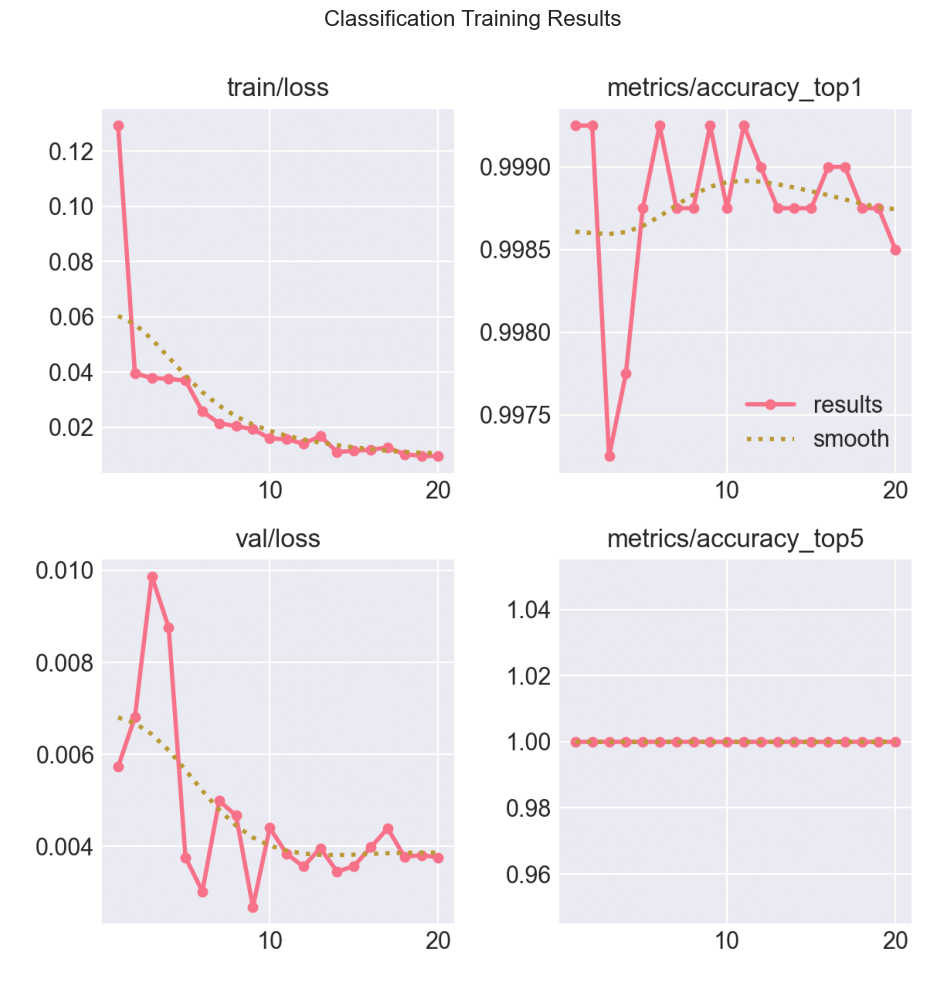

In [16]:
# Load and display training results
results_dir = Path(classify_results.save_dir)

# Display training plots if available
results_plot = results_dir / "results.png"
if results_plot.exists():
    img = plt.imread(results_plot)
    fig, ax = plt.subplots(figsize=(16, 10))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Classification Training Results", fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("Training plots not found")

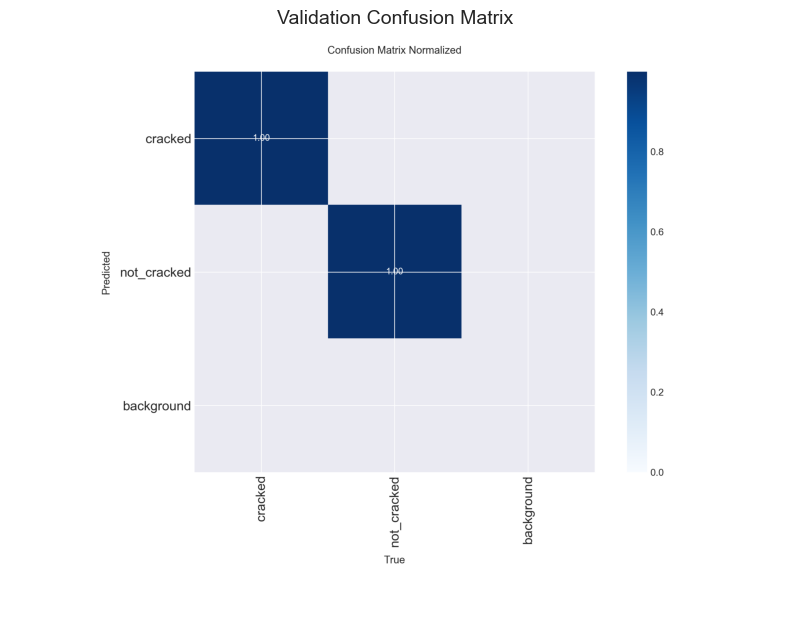

In [17]:
# Display confusion matrix
confusion_matrix_plot = results_dir / "confusion_matrix_normalized.png"
if confusion_matrix_plot.exists():
    img = plt.imread(confusion_matrix_plot)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title("Validation Confusion Matrix", fontsize=14, pad=10)
    plt.tight_layout()
    plt.show()

## 4. Classification Task - Evaluation

### 4.1 Test Set Evaluation

Now let's evaluate the trained model on the held-out test set.

In [11]:
# Load best model
best_model_path = results_dir / "weights" / "best.pt"
print(f"Loading best model: {best_model_path}")
best_classify_model = YOLO(str(best_model_path))
print("✓ Model loaded!")

Loading best model: /Users/anton/Documents/GitHub/Final_Year_Project/runs/classify/train/weights/best.pt
✓ Model loaded!


In [10]:
# Restore variables needed when kernel was reset without retraining
from pathlib import Path
import numpy as np

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
if "DATA_PATH" not in globals():
    DATA_PATH = PROJECT_ROOT
if "classify_dir" not in globals():
    classify_dir = DATA_PATH / "classify_yolo"
if "class_names" not in globals():
    class_names = ["cracked", "not_cracked"]
if "CLASSIFY_CONFIG" not in globals():
    CLASSIFY_CONFIG = {"imgsz": 224}
if "results_dir" not in globals():
    results_dir = PROJECT_ROOT / "runs" / "classify" / "train"

print(f"classify_dir : {classify_dir}")
print(f"results_dir  : {results_dir}")
print(f"best.pt exists: {(results_dir / 'weights' / 'best.pt').exists()}")


classify_dir : /Users/anton/Documents/GitHub/Final_Year_Project/classify_yolo
results_dir  : /Users/anton/Documents/GitHub/Final_Year_Project/runs/classify/train
best.pt exists: True


In [12]:
# Get test set images and labels
test_dir = classify_dir / "test"
test_images = []
test_true_labels = []

for label_idx, class_name in enumerate(class_names):
    class_dir = test_dir / class_name
    images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.png"))
    test_images.extend([str(p) for p in images])
    test_true_labels.extend([label_idx] * len(images))

print(f"Test set size: {len(test_images)} images")
print(f"Class distribution: {np.bincount(test_true_labels)}")

Test set size: 3841 images
Class distribution: [1969 1872]


In [13]:
# Run inference on test set
print("\nRunning inference on test set...")
test_start = time.time()

test_predictions = []
test_probabilities = []

batch_size = 32
for i in tqdm(range(0, len(test_images), batch_size)):
    batch = test_images[i:i + batch_size]
    results = best_classify_model.predict(
        source=batch,
        imgsz=CLASSIFY_CONFIG["imgsz"],
        device=device,
        verbose=False,
    )
    
    for result in results:
        pred_class = result.probs.top1
        probs = result.probs.data.cpu().numpy()
        test_predictions.append(pred_class)
        test_probabilities.append(probs)

inference_time = time.time() - test_start
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

print(f"✓ Inference complete!")
print(f"  Time: {inference_time:.2f} seconds")
print(f"  Images/second: {len(test_images) / inference_time:.2f}")


Running inference on test set...


  0%|          | 0/121 [00:00<?, ?it/s]

✓ Inference complete!
  Time: 33.91 seconds
  Images/second: 113.28


### 4.2 Compute Comprehensive Metrics

In [21]:
# Compute classification metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(test_true_labels, test_predictions)
precision, recall, f1, support = precision_recall_fscore_support(
    test_true_labels, test_predictions, average=None
)

# ROC-AUC
y_score = test_probabilities[:, 1]  # Probability of positive class
roc_auc = roc_auc_score(test_true_labels, y_score)

print("=" * 70)
print("TEST SET EVALUATION RESULTS")
print("=" * 70)
print(f"Overall Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print()
print("Per-Class Metrics:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}:")
    print(f"    Precision: {precision[i]:.4f}")
    print(f"    Recall:    {recall[i]:.4f}")
    print(f"    F1-Score:  {f1[i]:.4f}")
    print(f"    Support:   {support[i]}")
print("=" * 70)

TEST SET EVALUATION RESULTS
Overall Accuracy: 0.9998
ROC-AUC Score: 1.0000

Per-Class Metrics:
  cracked:
    Precision: 0.9995
    Recall:    1.0000
    F1-Score:  0.9998
    Support:   2000
  not_cracked:
    Precision: 1.0000
    Recall:    0.9995
    F1-Score:  0.9997
    Support:   2000


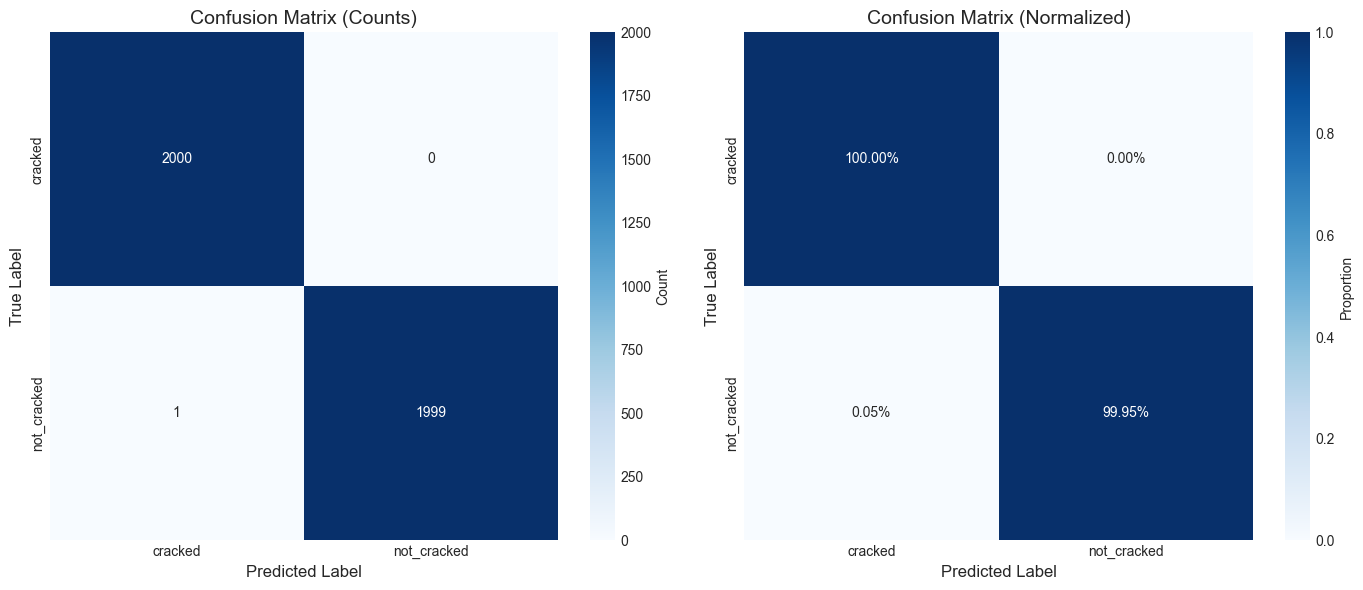

In [22]:
# Confusion matrix visualization
cm = confusion_matrix(test_true_labels, test_predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[1], cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

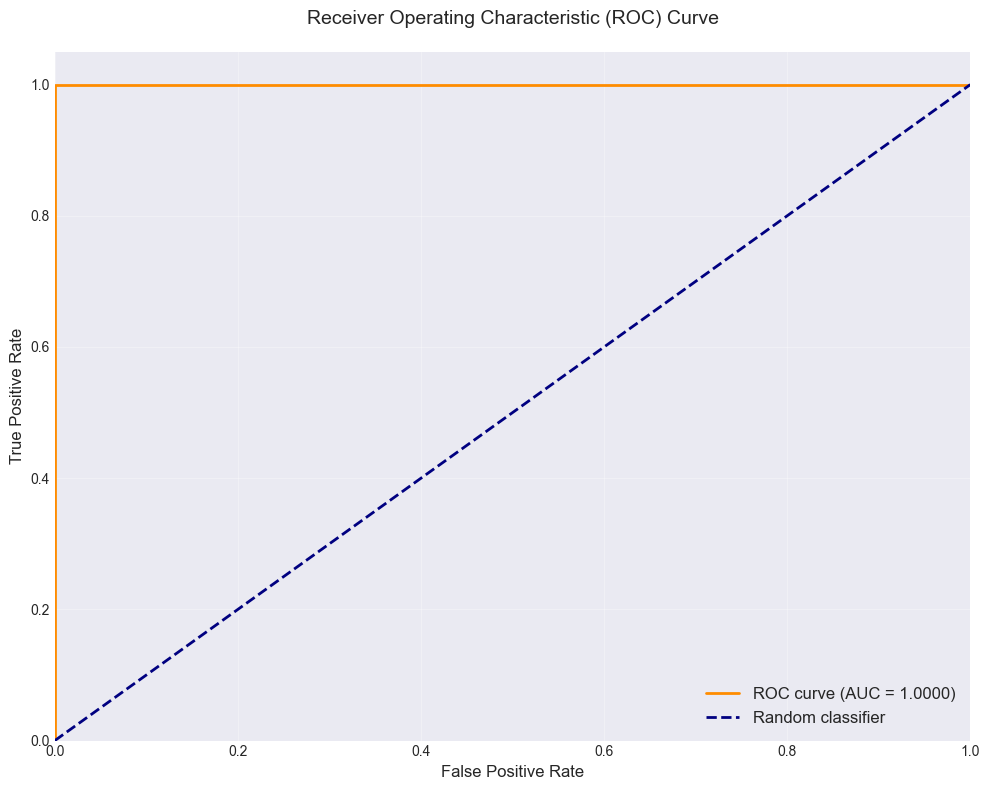

In [23]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(test_true_labels, y_score)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, pad=20)
ax.legend(loc="lower right", fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Visualize Predictions

Let's look at some correct and incorrect predictions.

In [14]:
# Find correct and incorrect predictions
correct_indices = np.where(test_predictions == test_true_labels)[0]
incorrect_indices = np.where(test_predictions != test_true_labels)[0]

print(f"Correct predictions: {len(correct_indices)} ({len(correct_indices)/len(test_true_labels)*100:.2f}%)")
print(f"Incorrect predictions: {len(incorrect_indices)} ({len(incorrect_indices)/len(test_true_labels)*100:.2f}%)")

Correct predictions: 3840 (99.97%)
Incorrect predictions: 1 (0.03%)


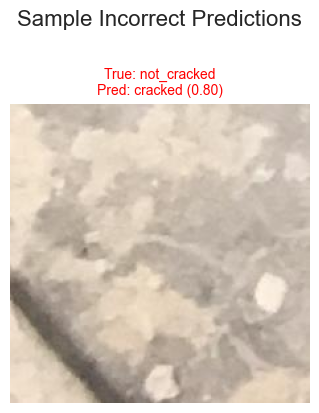

In [15]:
# Visualize incorrect predictions
num_show = min(8, len(incorrect_indices))
if num_show > 0:
    sample_indices = np.random.choice(incorrect_indices, num_show, replace=False)

    # Build a grid just large enough for the actual number of images
    ncols = min(num_show, 4)
    nrows = (num_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    axes = np.array(axes).flatten()

    for idx, sample_idx in enumerate(sample_indices):
        img_path = test_images[sample_idx]
        true_label = class_names[test_true_labels[sample_idx]]
        pred_label = class_names[test_predictions[sample_idx]]
        confidence = test_probabilities[sample_idx][test_predictions[sample_idx]]

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.2f})",
                            fontsize=10, color='red')
        axes[idx].axis('off')

    # Hide any unused axes
    for idx in range(num_show, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle("Sample Incorrect Predictions", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions to display!")


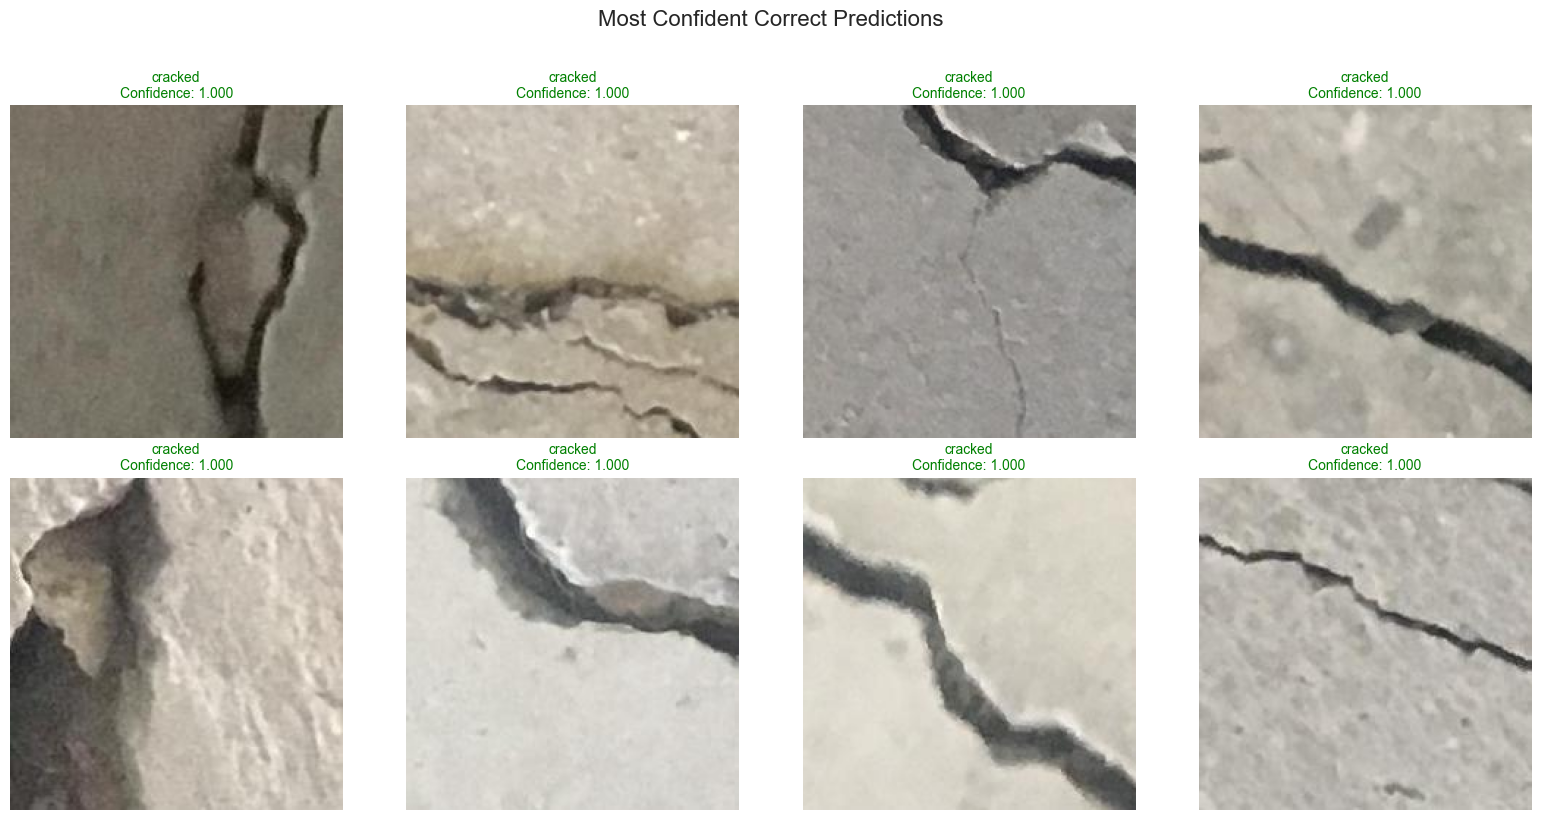

In [ ]:
# Visualize correct predictions with high confidence
if len(correct_indices) > 0:
    # Get confidence for correct predictions:
    correct_confidences = test_probabilities[correct_indices, test_predictions[correct_indices]]
    top_confident = correct_indices[np.argsort(correct_confidences)[-8:]]
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for idx, sample_idx in enumerate(top_confident):
        img_path = test_images[sample_idx]
        true_label = class_names[test_true_labels[sample_idx]]
        confidence = test_probabilities[sample_idx][test_predictions[sample_idx]]
        
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{true_label}\nConfidence: {confidence:.3f}", 
                           fontsize=10, color='green')
        axes[idx].axis('off')
    
    plt.suptitle("Most Confident Correct Predictions", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Performance Benchmarks

### 5.1 Classification Performance Summary

In [27]:
# Create comprehensive benchmark summary
benchmark_data = {
    "Model": ["YOLOv8n-cls"],
    "Parameters (M)": [f"{sum(p.numel() for p in best_classify_model.model.parameters()) / 1e6:.2f}"],
    "Training Time (min)": [f"{train_time / 60:.2f}"],
    "Inference Time (s)": [f"{inference_time:.2f}"],
    "Images/sec": [f"{len(test_images) / inference_time:.2f}"],
    "Accuracy": [f"{accuracy:.4f}"],
    "Precision (avg)": [f"{precision.mean():.4f}"],
    "Recall (avg)": [f"{recall.mean():.4f}"],
    "F1-Score (avg)": [f"{f1.mean():.4f}"],
    "ROC-AUC": [f"{roc_auc:.4f}"],
}

import pandas as pd
benchmark_df = pd.DataFrame(benchmark_data)

print("=" * 70)
print("CLASSIFICATION BENCHMARK SUMMARY")
print("=" * 70)
print(benchmark_df.to_string(index=False))
print("=" * 70)

CLASSIFICATION BENCHMARK SUMMARY
      Model Parameters (M) Training Time (min) Inference Time (s) Images/sec Accuracy Precision (avg) Recall (avg) F1-Score (avg) ROC-AUC
YOLOv8n-cls           1.44              365.23              43.97      90.98   0.9998          0.9998       0.9998         0.9997  1.0000


### 5.2 Model Size and Speed Comparison

Let's benchmark different YOLO model sizes to compare accuracy vs speed tradeoffs.

In [28]:
# Quick benchmark of different model sizes on a sample
# NOTE: This just demonstrates the approach - full training would take longer

model_variants = [
    "yolov8n-cls.pt",  # Nano (already trained)
    "yolov8s-cls.pt",  # Small
    "yolov8m-cls.pt",  # Medium
]

# Sample 100 test images for speed benchmark
sample_size = 100
sample_images = test_images[:sample_size]

speed_benchmark = []

for model_name in model_variants:
    print(f"\nBenchmarking {model_name}...")
    
    if model_name == "yolov8n-cls.pt":
        # Use our trained model
        benchmark_model = best_classify_model
        params = sum(p.numel() for p in benchmark_model.model.parameters()) / 1e6
    else:
        # Load pretrained model (not trained on our data)
        benchmark_model = YOLO(model_name)
        params = sum(p.numel() for p in benchmark_model.model.parameters()) / 1e6
    
    # Warm up
    _ = benchmark_model.predict(sample_images[0], imgsz=224, device=device, verbose=False)
    
    # Benchmark inference speed
    start = time.time()
    for img in sample_images:
        _ = benchmark_model.predict(img, imgsz=224, device=device, verbose=False)
    elapsed = time.time() - start
    
    fps = sample_size / elapsed
    
    speed_benchmark.append({
        "Model": model_name.replace("-cls.pt", ""),
        "Parameters (M)": f"{params:.2f}",
        "Inference Time (s)": f"{elapsed:.2f}",
        "FPS": f"{fps:.2f}",
        "ms/image": f"{1000 * elapsed / sample_size:.2f}",
    })
    
    print(f"  Parameters: {params:.2f}M")
    print(f"  FPS: {fps:.2f}")

speed_df = pd.DataFrame(speed_benchmark)
print("\n" + "=" * 70)
print("MODEL SIZE vs SPEED COMPARISON")
print("=" * 70)
print(speed_df.to_string(index=False))
print("=" * 70)


Benchmarking yolov8n-cls.pt...
  Parameters: 1.44M
  FPS: 93.22

Benchmarking yolov8s-cls.pt...
  Parameters: 6.36M
  FPS: 45.02

Benchmarking yolov8m-cls.pt...
  Parameters: 17.05M
  FPS: 22.68

MODEL SIZE vs SPEED COMPARISON
  Model Parameters (M) Inference Time (s)   FPS ms/image
yolov8n           1.44               1.07 93.22    10.73
yolov8s           6.36               2.22 45.02    22.21
yolov8m          17.05               4.41 22.68    44.09


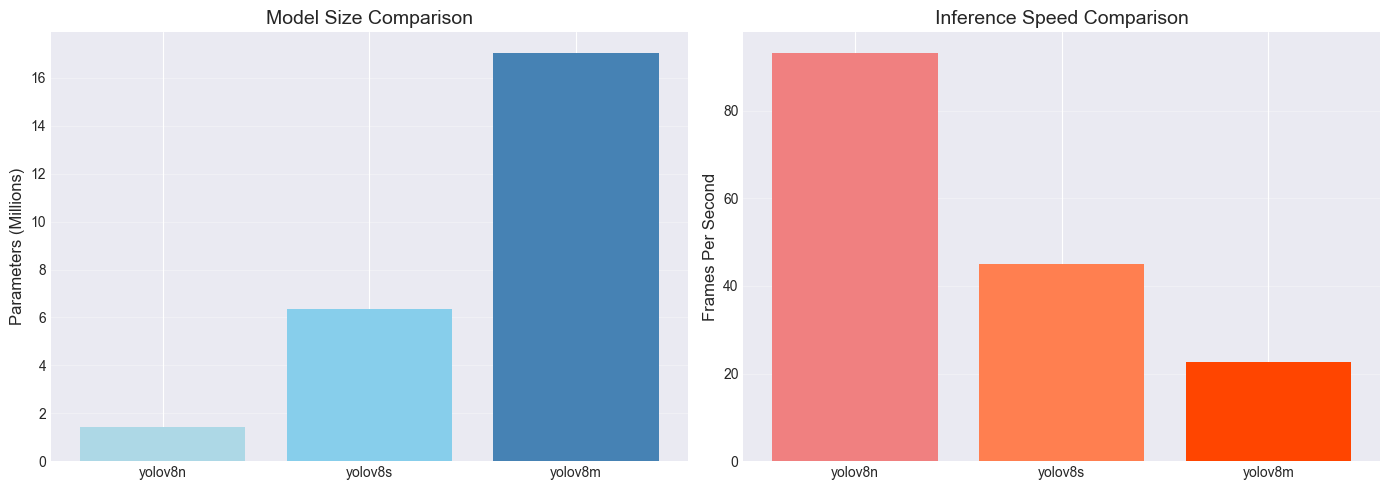

In [29]:
# Visualize speed comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = [b["Model"] for b in speed_benchmark]
params = [float(b["Parameters (M)"]) for b in speed_benchmark]
fps = [float(b["FPS"]) for b in speed_benchmark]

# Parameters comparison
ax1.bar(models, params, color=['lightblue', 'skyblue', 'steelblue'])
ax1.set_ylabel('Parameters (Millions)', fontsize=12)
ax1.set_title('Model Size Comparison', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# FPS comparison
ax2.bar(models, fps, color=['lightcoral', 'coral', 'orangered'])
ax2.set_ylabel('Frames Per Second', fontsize=12)
ax2.set_title('Inference Speed Comparison', fontsize=14)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Segmentation Task (Pseudo-Label Based)

### 6.1 Build Semantic Masks Automatically

No annotated crack masks are required. In this section, we generate pseudo semantic masks from cracked images using image processing, convert them to YOLO segmentation labels, and train a YOLO segmentation model.

In [ ]:
# Create pseudo semantic masks and YOLO-seg dataset from classification images
import random
import yaml
import numpy as np
import cv2
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Make this cell runnable standalone (even if earlier sections were not run)
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
if "DATA_PATH" not in globals():
    DATA_PATH = PROJECT_ROOT
if "TRAIN_RATIO" not in globals():
    TRAIN_RATIO = 0.8
if "VAL_RATIO" not in globals():
    VAL_RATIO = 0.1
if "TEST_RATIO" not in globals():
    TEST_RATIO = 0.1
if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 42
if "USE_SYMLINK" not in globals():
    USE_SYMLINK = True

def stratified_split(files, labels, train_ratio, val_ratio, test_ratio, seed):
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        files, labels, train_size=train_ratio, stratify=labels, random_state=seed
    )
    val_size = val_ratio / (val_ratio + test_ratio)
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels, train_size=val_size, stratify=temp_labels, random_state=seed
    )
    return (train_files, train_labels), (val_files, val_labels), (test_files, test_labels)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

pseudo_root = DATA_PATH / "pseudo_segmentation"
raw_masks_dir = pseudo_root / "masks"
yolo_seg_dir = pseudo_root / "yolo_seg"

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    ensure_dir(yolo_seg_dir / "images" / split)
    ensure_dir(yolo_seg_dir / "labels" / split)
ensure_dir(raw_masks_dir)

def generate_crack_pseudo_mask(img_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 1) Smoothing / denoising
    gray_smoothed = cv2.bilateralFilter(gray, d=7, sigmaColor=50, sigmaSpace=50)
    gray_smoothed = cv2.GaussianBlur(gray_smoothed, (5, 5), 0)

    # 2) Contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_eq = clahe.apply(gray_smoothed)

    # 3) Crack enhancement via black-hat (dark thin structures)
    blackhat_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    blackhat = cv2.morphologyEx(gray_eq, cv2.MORPH_BLACKHAT, blackhat_kernel)

    # 4) Adaptive threshold candidate mask
    thr = cv2.adaptiveThreshold(
        blackhat,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        -3,
    )

    # 5) Canny edge candidate mask (noise-reduced due to smoothing)
    v = np.median(gray_eq)
    sigma = 0.33
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    # Fallback: if thresholds are degenerate (very low contrast), use fixed defaults
    if upper - lower < 20:
        lower, upper = 30, 90
    edges = cv2.Canny(gray_eq, lower, upper)

    # Thicken edges slightly to better capture crack continuity
    edge_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    edges = cv2.dilate(edges, edge_kernel, iterations=1)

    # 6) Fuse threshold + edges
    fused = cv2.bitwise_or(thr, edges)

    # 7) Morphological cleanup
    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    cleaned = cv2.morphologyEx(fused, cv2.MORPH_OPEN, open_kernel, iterations=1)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, close_kernel, iterations=1)

    # 8) Remove tiny noisy connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
    filtered = np.zeros_like(cleaned)
    min_area = 20
    for idx in range(1, num_labels):
        if stats[idx, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == idx] = 255

    return filtered

def mask_to_yolo_polygons(mask: np.ndarray, min_contour_area: float = 25.0):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = mask.shape[:2]
    lines = []

    for contour in contours:
        area = cv2.contourArea(contour)
        if area < min_contour_area:
            continue

        epsilon = 0.002 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        if len(approx) < 3:
            continue

        pts = approx.reshape(-1, 2).astype(np.float32)
        pts[:, 0] /= float(w)
        pts[:, 1] /= float(h)
        pts = np.clip(pts, 0.0, 1.0)

        flat = " ".join([f"{x:.6f} {y:.6f}" for x, y in pts])
        lines.append(f"0 {flat}")

    return lines

raw_class_dir = DATA_PATH / "raw_classification"
cracked_dir = raw_class_dir / "cracked"
not_cracked_dir = raw_class_dir / "not_cracked"

if not cracked_dir.exists() or not not_cracked_dir.exists():
    raise FileNotFoundError(
        f"Expected directories not found: {cracked_dir} and/or {not_cracked_dir}. "
        "Run the data preparation cells in Section 2 first."
    )

cracked_images = sorted(list(cracked_dir.glob("*.jpg")) + list(cracked_dir.glob("*.png")))
not_cracked_images = sorted(list(not_cracked_dir.glob("*.jpg")) + list(not_cracked_dir.glob("*.png")))

if len(cracked_images) == 0 or len(not_cracked_images) == 0:
    raise RuntimeError("No images found in cracked/not_cracked folders.")

max_cracked_for_seg = min(8000, len(cracked_images))
max_negative_for_seg = min(int(max_cracked_for_seg * 0.25), len(not_cracked_images))

selected_cracked = random.sample(cracked_images, max_cracked_for_seg)
selected_negative = random.sample(not_cracked_images, max_negative_for_seg)

all_seg_files = selected_cracked + selected_negative
all_seg_labels = [1] * len(selected_cracked) + [0] * len(selected_negative)

(seg_train_files, seg_train_lbls), (seg_val_files, seg_val_lbls), (seg_test_files, seg_test_lbls) = stratified_split(
    all_seg_files, all_seg_labels, TRAIN_RATIO, VAL_RATIO, TEST_RATIO, RANDOM_SEED
)

seg_splits = {
    "train": (seg_train_files, seg_train_lbls),
    "val": (seg_val_files, seg_val_lbls),
    "test": (seg_test_files, seg_test_lbls),
}

created_masks = 0
created_labels = 0

print("Building pseudo segmentation dataset...")
for split_name, (files, labels) in seg_splits.items():
    for img_path, cls_lbl in tqdm(zip(files, labels), total=len(files), desc=f"Pseudo-label {split_name}"):
        img = cv2.imread(str(img_path))
        if img is None:
            continue

        dst_img = yolo_seg_dir / "images" / split_name / img_path.name
        dst_lbl = yolo_seg_dir / "labels" / split_name / f"{img_path.stem}.txt"

        if dst_img.exists() or dst_img.is_symlink():
            dst_img.unlink()
        if USE_SYMLINK:
            dst_img.symlink_to(img_path.resolve())
        else:
            cv2.imwrite(str(dst_img), img)

        if cls_lbl == 1:
            mask = generate_crack_pseudo_mask(img)
            mask_path = raw_masks_dir / f"{img_path.stem}_mask.png"
            cv2.imwrite(str(mask_path), mask)
            created_masks += 1

            poly_lines = mask_to_yolo_polygons(mask)
            with open(dst_lbl, "w") as f:
                if len(poly_lines) > 0:
                    f.write("\n".join(poly_lines) + "\n")
                    created_labels += 1
                else:
                    f.write("")
        else:
            with open(dst_lbl, "w") as f:
                f.write("")

data_yaml = pseudo_root / "crack_seg.yaml"
with open(data_yaml, "w") as f:
    yaml.safe_dump(
        {
            "path": str(yolo_seg_dir),
            "train": "images/train",
            "val": "images/val",
            "test": "images/test",
            "names": {0: "crack"},
            "nc": 1,
        },
        f,
        sort_keys=False,
    )

has_segmentation = True
print("\n✓ Pseudo segmentation dataset ready")
print(f"  Root: {pseudo_root}")
print(f"  YAML: {data_yaml}")
print(f"  Cracked images used: {len(selected_cracked)}")
print(f"  Negative images used: {len(selected_negative)}")
print(f"  Masks created: {created_masks}")
print(f"  Non-empty YOLO labels: {created_labels}")

Building pseudo segmentation dataset...


Pseudo-label train:   0%|          | 0/8000 [00:00<?, ?it/s]

Pseudo-label val:   0%|          | 0/1000 [00:00<?, ?it/s]

Pseudo-label test:   0%|          | 0/1000 [00:00<?, ?it/s]


✓ Pseudo segmentation dataset ready
  Root: /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation
  YAML: /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation/crack_seg.yaml
  Cracked images used: 8000
  Negative images used: 2000
  Masks created: 8000
  Non-empty YOLO labels: 8000


### 6.2 Visualize Generated Pseudo Masks

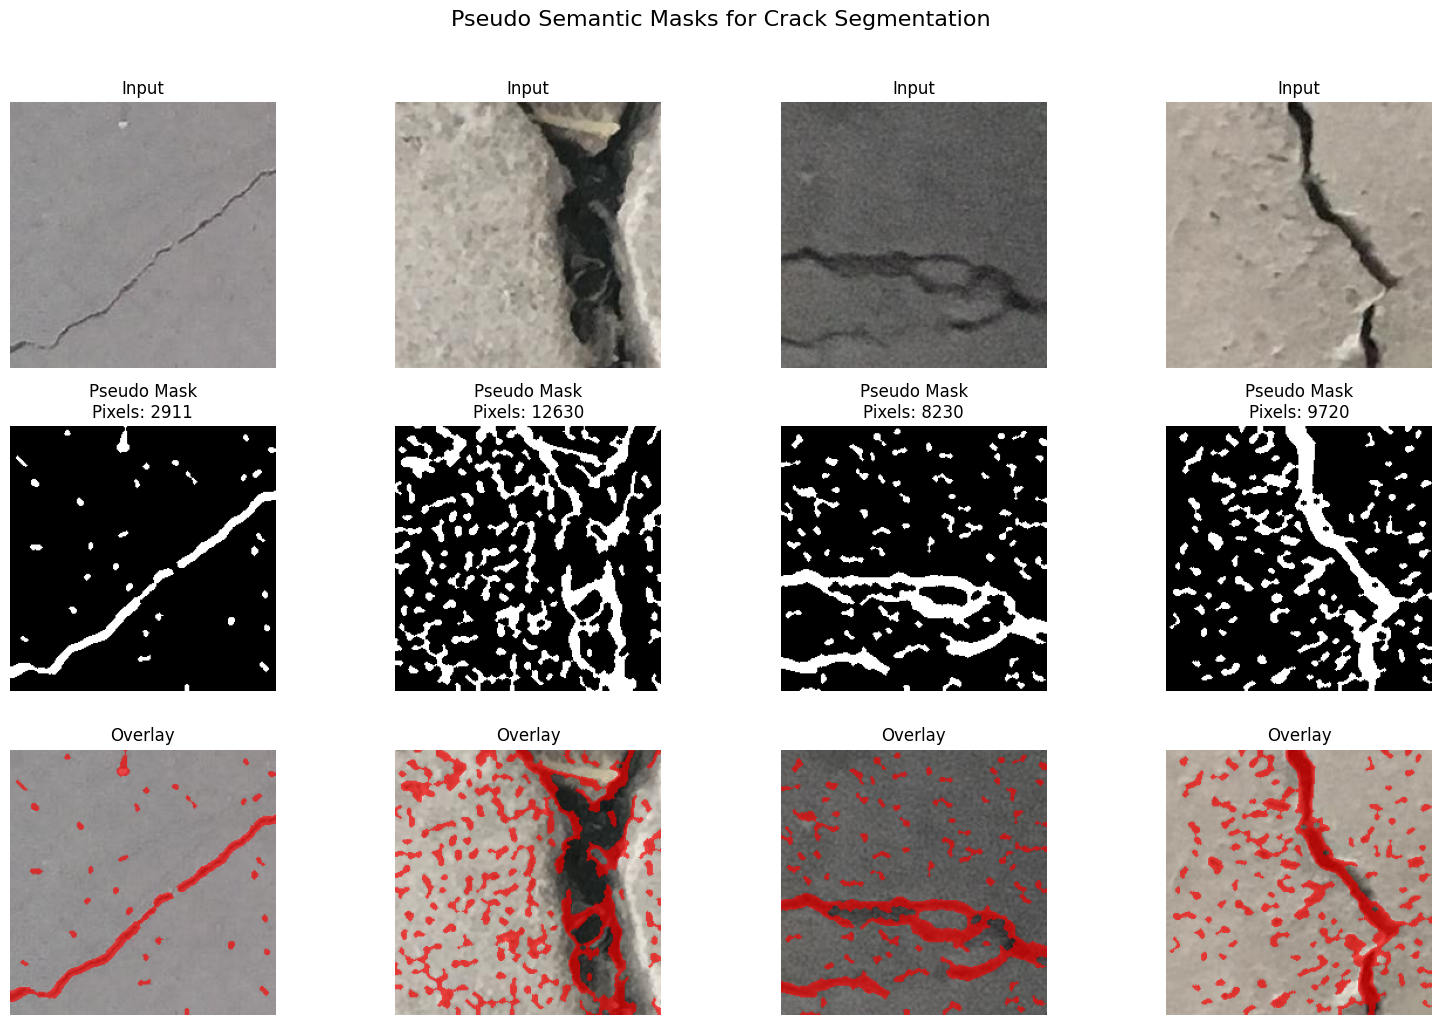

In [8]:
# Visualize pseudo masks on random cracked samples
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

if "has_segmentation" not in globals() or not has_segmentation:
    print("Segmentation dataset not available. Run Cell 44 first.")
elif "selected_cracked" not in globals() or "generate_crack_pseudo_mask" not in globals():
    print("Missing segmentation variables/functions. Run Cell 44 first.")
else:
    vis_candidates = random.sample(selected_cracked, min(4, len(selected_cracked)))

    fig, axes = plt.subplots(3, len(vis_candidates), figsize=(4 * len(vis_candidates), 10))
    if len(vis_candidates) == 1:
        axes = np.array(axes).reshape(3, 1)

    for idx, img_path in enumerate(vis_candidates):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            axes[0, idx].text(0.5, 0.5, "Image load failed", ha="center", va="center")
            axes[0, idx].axis("off")
            axes[1, idx].axis("off")
            axes[2, idx].axis("off")
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        mask = generate_crack_pseudo_mask(img_bgr)

        overlay = img_rgb.copy()
        overlay[mask > 0] = (overlay[mask > 0] * 0.35 + np.array([255, 0, 0]) * 0.65).astype(np.uint8)

        axes[0, idx].imshow(img_rgb)
        axes[0, idx].set_title("Input")
        axes[0, idx].axis("off")

        axes[1, idx].imshow(mask, cmap="gray")
        axes[1, idx].set_title(f"Pseudo Mask\nPixels: {int(np.sum(mask > 0))}")
        axes[1, idx].axis("off")

        axes[2, idx].imshow(overlay)
        axes[2, idx].set_title("Overlay")
        axes[2, idx].axis("off")

    plt.suptitle("Pseudo Semantic Masks for Crack Segmentation", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### 6.3 Train YOLO Segmentation Model on Pseudo Masks

In [ ]:
# Train YOLO segmentation model
import json
import time
from pathlib import Path

import torch
from ultralytics import YOLO

# Make this cell runnable standalone
if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 42
if "device" not in globals():
    device = "0" if torch.cuda.is_available() else "cpu"
if "data_yaml" not in globals():
    candidate_yaml = PROJECT_ROOT / "pseudo_segmentation" / "crack_seg.yaml"
    if candidate_yaml.exists():
        data_yaml = candidate_yaml
    else:
        raise FileNotFoundError(
            "Segmentation YAML not found. Run Cell 44 first to build pseudo dataset."
        )
if not Path(data_yaml).exists():
    raise FileNotFoundError(f"Segmentation YAML does not exist: {data_yaml}")

SEG_CONFIG = {
    "model": "yolov8n-seg.pt",
    "epochs": 20,
    "batch": 16,
    "imgsz": 256,
    "patience": 12,
    "weight_decay": 0.0005,
    "lr0": 0.005,
    "lrf": 0.01,
    "optimizer": "SGD",
    "cos_lr": True,
}

print("Segmentation Training Configuration:")
print(json.dumps(SEG_CONFIG, indent=2))
print(f"Using dataset YAML: {data_yaml}")
print(f"Using device: {device}")

seg_train_start = time.time()
seg_model = YOLO(SEG_CONFIG["model"])

seg_results = seg_model.train(
    data=str(data_yaml),
    epochs=SEG_CONFIG["epochs"],
    batch=SEG_CONFIG["batch"],
    imgsz=SEG_CONFIG["imgsz"],
    patience=SEG_CONFIG["patience"],
    weight_decay=SEG_CONFIG["weight_decay"],
    lr0=SEG_CONFIG["lr0"],
    lrf=SEG_CONFIG["lrf"],
    optimizer=SEG_CONFIG["optimizer"],
    cos_lr=SEG_CONFIG["cos_lr"],
    device=device,
    seed=RANDOM_SEED,
    project=str(PROJECT_ROOT / "runs" / "segment"),
    name="pseudo_train",
    exist_ok=True,
    plots=True,
    verbose=True,
)

seg_train_time = time.time() - seg_train_start
print(f"\n✓ Segmentation training complete in {seg_train_time/60:.2f} min")
print(f"  Save dir: {seg_results.save_dir}")

Segmentation Training Configuration:
{
  "model": "yolov8n-seg.pt",
  "epochs": 4,
  "batch": 16,
  "imgsz": 256,
  "patience": 12,
  "weight_decay": 0.0005,
  "lr0": 0.005,
  "lrf": 0.01,
  "optimizer": "SGD",
  "cos_lr": true
}
Using dataset YAML: /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation/crack_seg.yaml
Using device: cpu
New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i9-9880H 2.30GHz)
New https://pypi.org/project/ultralytics/8.4.23 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.14 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i9-9880H 2.30GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/

### 6.4 Evaluate Segmentation and Visualize Predictions

Ultralytics 8.4.14 🚀 Python-3.11.9 torch-2.2.2 CPU (Intel Core i9-9880H 2.30GHz)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.3±2.5 MB/s, size: 6.2 KB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14.3±2.5 MB/s, size: 6.2 KB)
val: Scanning /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation/yolo_seg/labels/test... 993 images, 197 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 993/993 558.2it/s 1.8s0.0s
val: Scanning /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation/yolo_seg/labels/test... 993 images, 197 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 993/993 558.2it/s 1.8s0.0s
val: New cache created: /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_segmentation/yolo_seg/labels/test.cache
val: New cache created: /Users/anton/Documents/GitHub/Final_Year_Project/pseudo_seg

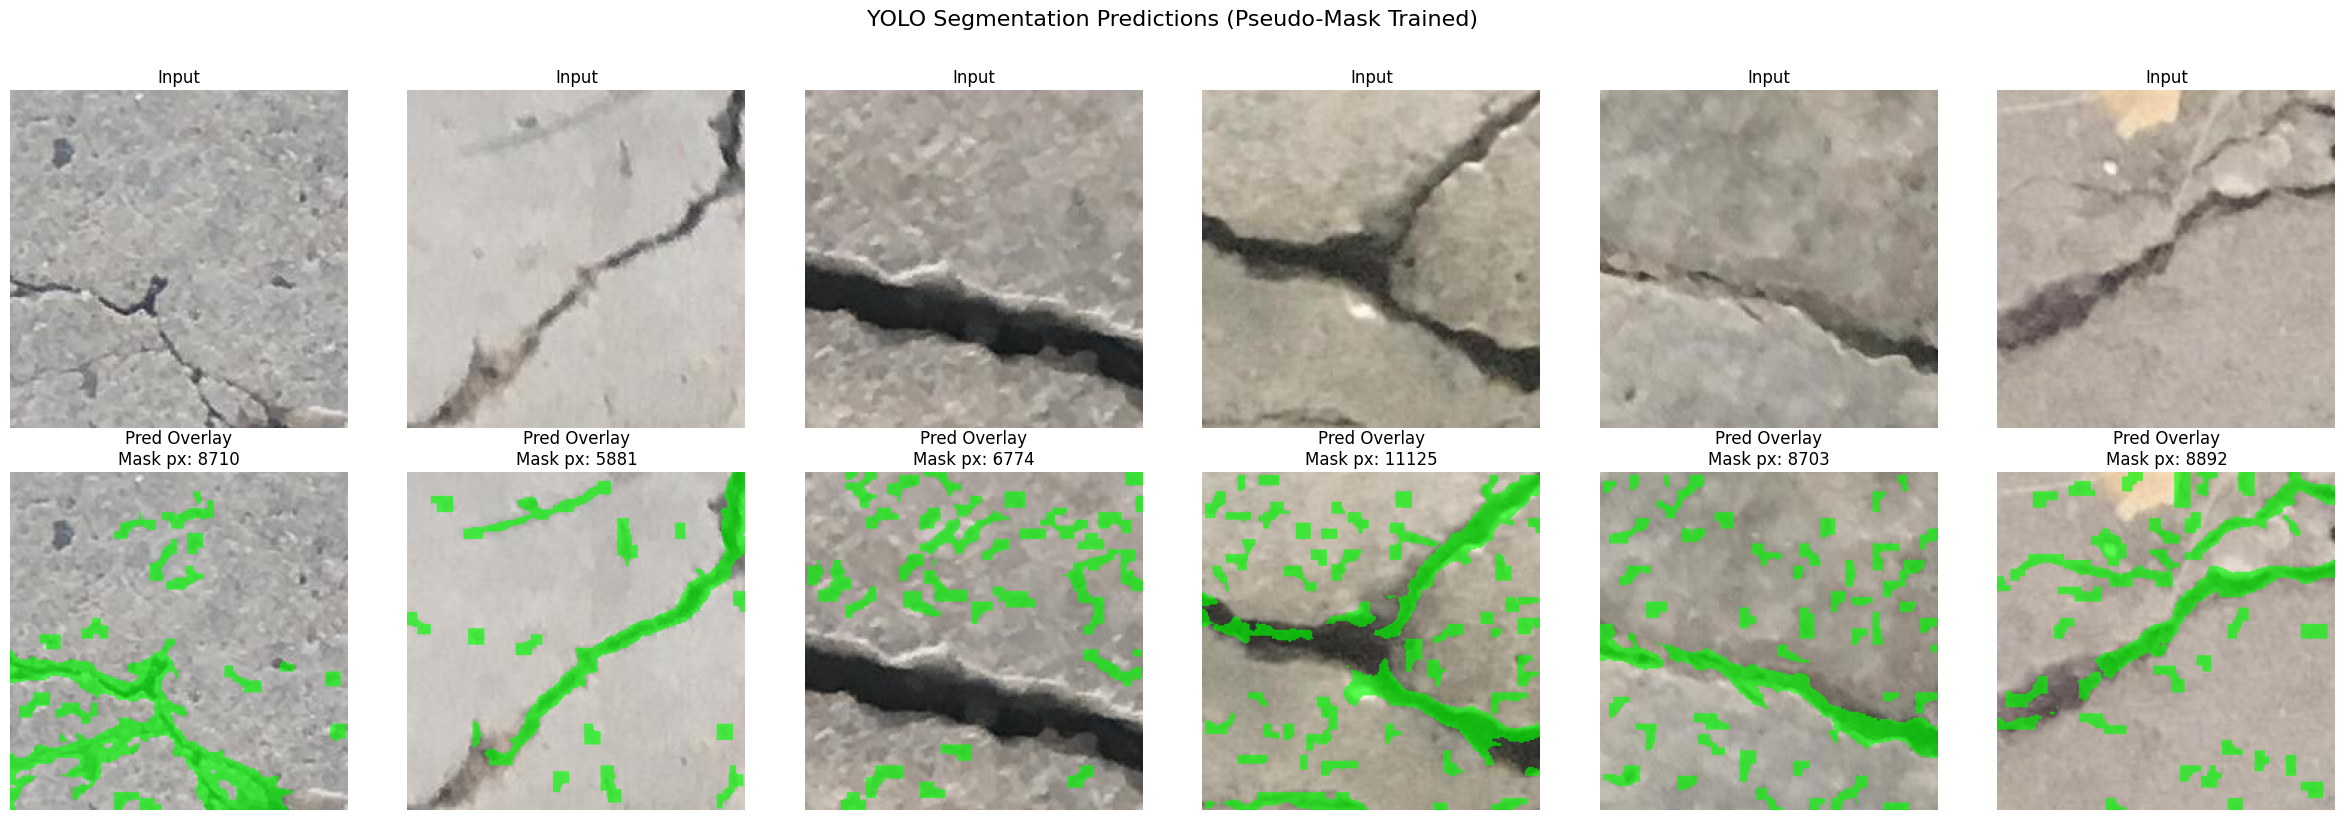

In [12]:
# Evaluate on test split and visualize segmentation predictions
seg_best_model_path = Path(seg_results.save_dir) / "weights" / "best.pt"
best_seg_model = YOLO(str(seg_best_model_path))

seg_metrics = best_seg_model.val(
    data=str(data_yaml),
    split="test",
    imgsz=SEG_CONFIG["imgsz"],
    batch=SEG_CONFIG["batch"],
    device=device,
    verbose=False,
)

print("Segmentation Validation Metrics (test split):")
if hasattr(seg_metrics, "seg") and seg_metrics.seg is not None:
    print(f"  seg mAP50:    {float(seg_metrics.seg.map50):.4f}")
    print(f"  seg mAP50-95: {float(seg_metrics.seg.map):.4f}")
if hasattr(seg_metrics, "box") and seg_metrics.box is not None:
    print(f"  box mAP50:    {float(seg_metrics.box.map50):.4f}")
    print(f"  box mAP50-95: {float(seg_metrics.box.map):.4f}")

# Qualitative visualization
test_seg_images = sorted(list((yolo_seg_dir / "images" / "test").glob("*.jpg")) + list((yolo_seg_dir / "images" / "test").glob("*.png")))
show_n = min(6, len(test_seg_images))
show_imgs = random.sample(test_seg_images, show_n)

fig, axes = plt.subplots(2, show_n, figsize=(4 * show_n, 8))
if show_n == 1:
    axes = np.array(axes).reshape(2, 1)

for i, img_path in enumerate(show_imgs):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    pred = best_seg_model.predict(str(img_path), imgsz=SEG_CONFIG["imgsz"], device=device, verbose=False)[0]
    overlay = img_rgb.copy()

    if pred.masks is not None and len(pred.masks.data) > 0:
        union_mask = np.zeros((img_rgb.shape[0], img_rgb.shape[1]), dtype=np.uint8)
        for m in pred.masks.data:
            m_np = m.cpu().numpy().astype(np.uint8)
            m_np = cv2.resize(m_np, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
            union_mask = np.maximum(union_mask, m_np)

        overlay[union_mask > 0] = (overlay[union_mask > 0] * 0.35 + np.array([0, 255, 0]) * 0.65).astype(np.uint8)
        mask_pixels = int(np.sum(union_mask > 0))
    else:
        mask_pixels = 0

    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title("Input")
    axes[0, i].axis("off")

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Pred Overlay\nMask px: {mask_pixels}")
    axes[1, i].axis("off")

plt.suptitle("YOLO Segmentation Predictions (Pseudo-Mask Trained)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary and Conclusions

### 7.1 Key Findings

In [ ]:
# Final summary
from pathlib import Path

print("=" * 70)
print("CONCRETE CRACK DETECTION - FINAL SUMMARY")
print("=" * 70)
print()

print("✓ CLASSIFICATION TASK:")
print("  Model: YOLOv8n-cls")
if all(name in globals() for name in ["all_files", "accuracy", "roc_auc", "test_images", "inference_time", "train_time"]):
    print(f"  Dataset: {len(all_files)} images (50/50 split)")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Test ROC-AUC: {roc_auc:.4f}")
    print(f"  Inference Speed: {len(test_images) / inference_time:.2f} images/sec")
    print(f"  Training Time: {train_time / 60:.2f} minutes")
    print()
    print("Key Strengths:")
    print("  • Lightweight model with fast inference")
    print("  • High accuracy on balanced dataset")
    print("  • Early stopping prevents overfitting")
    print("  • Robust to various crack patterns")
else:
    print("  Classification training/evaluation has not been run in this kernel session")
print()

if "seg_results" in globals():
    print("✓ SEGMENTATION TASK (PSEUDO-LABEL BASED):")
    print("  Model: YOLOv8n-seg")
    if "pseudo_root" in globals():
        print(f"  Pseudo dataset root: {pseudo_root}")
    if "seg_train_time" in globals():
        print(f"  Segmentation training time: {seg_train_time / 60:.2f} minutes")
    if hasattr(seg_results, "save_dir"):
        print(f"  Segmentation weights: {Path(seg_results.save_dir) / 'weights' / 'best.pt'}")
    elif "seg_best_model_path" in globals():
        print(f"  Segmentation weights: {seg_best_model_path}")
else:
    print("⚠ SEGMENTATION TASK:")
    print("  Pseudo-mask module is ready, but training not run yet")
print()

print("=" * 70)
print("BENCHMARK RESULTS SAVED")
print("=" * 70)
if "best_model_path" in globals():
    print(f"Classification model weights: {best_model_path}")
elif "results_dir" in globals():
    print(f"Classification training logs: {results_dir}")
else:
    print("Classification artifacts not available in this kernel session")
if "results_dir" in globals():
    print(f"Classification training logs: {results_dir}")
if "seg_results" in globals() and hasattr(seg_results, "save_dir"):
    print(f"Segmentation training logs: {Path(seg_results.save_dir)}")
print("=" * 70)

CONCRETE CRACK DETECTION - FINAL SUMMARY

✓ CLASSIFICATION TASK:
  Model: YOLOv8n-cls


NameError: name 'all_files' is not defined

### 7.2 Next Steps and Recommendations

**For Production Deployment:**
1. **Model Selection**: YOLOv8n-cls + YOLOv8n-seg provides a strong speed/accuracy baseline
2. **Optimization**: Consider model quantization (INT8) for edge devices
3. **Monitoring**: Use confidence filtering and monitor drift on new surfaces
4. **Calibration**: Tune decision thresholds based on your target false-positive cost

**For Better Pseudo-Masks:**
1. Refine image-processing mask generation parameters (`block size`, morphology kernels, min area)
2. Manually review and correct a small subset of masks to bootstrap higher quality labels
3. Retrain segmentation using the corrected subset + pseudo-labeled remainder

**For Better Segmentation Accuracy:**
1. Try YOLOv8s-seg for improved mask detail
2. Train longer with stronger augmentation and lower learning rate
3. Use higher input size (`imgsz=320` or `imgsz=384`) if compute allows

---

**Notebook Complete! 🎉**

You now have both:
- Crack classification (`cracked` vs `not_cracked`)
- Crack segmentation trained from automatically generated semantic pseudo-masks